In [1]:
# imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = Path.cwd().parent.parent.joinpath("processed_data", "candidates.csv")
data

WindowsPath('c:/Users/brian/OneDrive - University of Illinois - Urbana/team-nuclear-family/processed_data/candidates.csv')

In [3]:
df = pd.read_csv(data).drop(columns = "Unnamed: 0")

# add a binary variable of having nuclear plants or not
df["has_plant"] = (df["plant_count"] > 0).astype(int)

df

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,16.455467,10.0,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,2.165857,18.0,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,10.562934,3.0,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,6.887895,4.0,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,1.588568,44.0,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2156,21079,Garrard County,18207.0,58263.0,7284.0,282164.0,0.0,2.906966e+07,0.047976,1,...,2.328877,15.0,345.0,92.000000,49.0,1.271817e+07,0.020990,605.917102,30.048665,0
2157,53065,Stevens County,49668.0,62381.0,22312.0,536848.0,0.0,1.749183e+05,0.000027,27,...,71.466142,0.0,0.0,0.000000,116.0,2.801182e+08,0.042580,6578.600470,7.549934,0
2158,19177,Van Buren County,7131.0,58417.0,3509.0,126206.0,0.0,1.457009e+08,0.114681,5,...,6.011057,8.0,69.0,69.000000,37.0,3.431825e+07,0.027012,1270.486217,5.612812,0
2159,31073,Gosper County,1803.0,76583.0,1193.0,33218.0,0.0,8.760107e+07,0.073095,4,...,2.795926,19.0,115.0,93.210526,4.0,8.381496e+06,0.006994,1198.448014,1.504446,0


In [4]:
df.columns

Index(['geo_id', 'county_name', 'population', 'median_household_income',
       'housing_units', 'total_energy_consumption_mwh', 'data_centers_count',
       'sfha_area', 'pct_sfha', 'lake_count', 'total_lake_area', 'avg_vol',
       'avg_depth', 'avg_discharge', 'dist_to_lakes_km', 'wetland_count',
       'distance_to_rivers_km', 'rivers_count', 'total_rivers_mile',
       'military_count', 'total_military_area_m', 'pct_military',
       'plant_count', 'pga_max', 'distance_to_lines_km',
       'transmission_lines_count', 'max_voltage', 'average_voltage',
       'protected_count', 'total_protected_area_m', 'pct_protected',
       'county_area_km2', 'population_density', 'has_plant'],
      dtype='object')

In [5]:
# some variables are better if they have a higher value; 
# while others are better if they have a lower value

higher_better = [
    "avg_vol",
    "total_lake_area", 
    "max_voltage",
    "total_energy_consumption_mwh",
    "data_centers_count"
]

lower_better = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "pct_military",
    "pct_protected",
]

scored_features = higher_better + lower_better

In [6]:
# normalize features used for scoring 
# 1 = the most suitable, regardless of original direction

scaler = MinMaxScaler()
df_scaled = df[scored_features].copy()
df_scaled[scored_features] = scaler.fit_transform(df[scored_features])
df_scaled[lower_better] = 1 - df_scaled[lower_better]
df_scaled

,avg_vol,total_lake_area,max_voltage,total_energy_consumption_mwh,data_centers_count,pga_max,pct_sfha,population_density,dist_to_lakes_km,distance_to_lines_km,pct_military,pct_protected
0,1.690123e-05,0.000317,0.180392,0.002878,0.0,0.400000,0.603510,0.999679,0.986837,0.997318,1.000000,0.845434
1,1.238854e-06,0.000322,0.090196,0.003109,0.0,0.830000,0.364290,0.999223,0.994047,0.999656,1.000000,0.233745
2,1.781687e-05,0.000126,0.300654,0.005414,0.0,0.726667,0.701384,0.997856,0.992635,0.998282,1.000000,0.872495
3,0.000000e+00,0.000000,0.090196,0.001929,0.0,0.500000,1.000000,0.999946,0.660070,0.998884,1.000000,0.649459
4,4.434156e-07,0.000022,0.450980,0.041140,0.0,0.676667,0.534114,0.982919,0.977931,0.999750,0.800244,0.894681
...,...,...,...,...,...,...,...,...,...,...,...,...
2156,1.169959e-04,0.000052,0.450980,0.005162,0.0,0.600000,0.759658,0.996828,0.964064,0.999629,1.000000,0.789230
2157,1.024240e-04,0.002149,0.000000,0.009844,0.0,0.500000,0.999867,0.999205,0.961113,0.988320,1.000000,0.572432
2158,6.831275e-07,0.000017,0.090196,0.002295,0.0,0.783333,0.425493,0.999410,0.976903,0.999027,1.000000,0.728761
2159,1.372736e-05,0.000088,0.150327,0.000585,0.0,0.856667,0.633821,0.999844,0.969348,0.999553,1.000000,0.929774


In [7]:
criteria_ranking = {
    "pga_max": 1,
    "pct_sfha": 2,
    "population_density": 3,
    "dist_to_lakes_km": 4,
    "avg_vol": 5,
    "total_lake_area": 6,
    "distance_to_lines_km": 7,
    "max_voltage": 8,
    "total_energy_consumption_mwh": 9,
    "data_centers_count": 10,
    "pct_military": 11,
    "pct_protected": 12,
}

In [8]:
n = len(criteria_ranking)

weights = []
for i in range(1, n + 1):
    weight = sum(1 / j for j in range (i, n + 1)) / n
    weights.append(weight)

# all weights in mcda scoring add up to 1
assert sum(weights) == 1
weights

[0.25860088985088986,
 0.17526755651755652,
 0.13360088985088983,
 0.10582311207311207,
 0.08498977873977874,
 0.06832311207311208,
 0.05443422318422319,
 0.04252946127946128,
 0.032112794612794614,
 0.02285353535353535,
 0.014520202020202022,
 0.006944444444444444]

In [9]:
criteria_weights = {}

for index, criteria in enumerate(criteria_ranking.keys()):
    criteria_weights[criteria] = weights[index]

criteria_weights

{'pga_max': 0.25860088985088986,
 'pct_sfha': 0.17526755651755652,
 'population_density': 0.13360088985088983,
 'dist_to_lakes_km': 0.10582311207311207,
 'avg_vol': 0.08498977873977874,
 'total_lake_area': 0.06832311207311208,
 'distance_to_lines_km': 0.05443422318422319,
 'max_voltage': 0.04252946127946128,
 'total_energy_consumption_mwh': 0.032112794612794614,
 'data_centers_count': 0.02285353535353535,
 'pct_military': 0.014520202020202022,
 'pct_protected': 0.006944444444444444}

In [10]:
df['mcda_score'] = sum(df_scaled[feat] * weight for feat, weight in criteria_weights.items())
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,transmission_lines_count,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,10.0,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,18.0,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,3.0,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,4.0,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,44.0,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162


In [11]:
df["rank"] = df["mcda_score"].rank(ascending=False, method="min")
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


In [12]:
df.nsmallest(20, "rank")

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
988,55079,Milwaukee County,924216.0,59319.0,423764.0,10823586.0,3.0,8.721398e+07,2.830865e-02,2,...,230.0,140.666667,22.0,1.183508e+06,0.000384,3080.824526,299.989822,0,0.810858,1.0
2028,26131,Ontonagon County,5823.0,48316.0,5271.0,57974.0,0.0,0.000000e+00,0.000000e+00,19,...,69.0,69.000000,43.0,2.122554e+08,0.021910,9687.681113,0.601073,0,0.794073,2.0
183,55003,Ashland County,16203.0,57000.0,9415.0,188534.0,0.0,1.056269e+05,1.779071e-05,26,...,115.0,115.000000,53.0,3.461448e+08,0.058301,5937.192078,2.729068,0,0.789878,3.0
2051,26003,Alger County,8641.0,55528.0,6208.0,87694.0,0.0,4.654517e+01,3.560291e-09,48,...,138.0,75.900000,67.0,5.605771e+08,0.042879,13073.416751,0.660960,0,0.784472,4.0
1139,26061,Houghton County,37842.0,52736.0,18687.0,368894.0,0.0,4.800869e+01,1.234503e-08,32,...,138.0,81.545455,169.0,2.694581e+08,0.069289,3888.907788,9.730753,0,0.783513,5.0
1728,26009,Antrim County,24698.0,68850.0,17596.0,230548.0,0.0,4.645868e+05,2.980910e-04,35,...,345.0,118.285714,38.0,1.609487e+07,0.010327,1558.540018,15.846882,0,0.777135,6.0
173,26053,Gogebic County,14285.0,47913.0,10405.0,146219.0,0.0,1.124239e+05,2.939451e-05,111,...,115.0,92.000000,38.0,2.492638e+08,0.065173,3824.656581,3.734976,0,0.773048,7.0
244,26103,Marquette County,68064.0,63115.0,33584.0,656018.0,0.0,1.836763e+08,2.070585e-02,143,...,345.0,114.342857,82.0,2.142223e+08,0.024149,8870.744429,7.672862,0,0.771867,8.0
1055,55061,Kewaunee County,20758.0,77610.0,9280.0,241942.0,0.0,7.769844e+07,2.766758e-02,5,...,138.0,92.000000,40.0,1.230636e+07,0.004382,2808.284579,7.391701,0,0.770808,9.0
665,26047,Emmet County,33775.0,69690.0,21791.0,334066.0,0.0,1.176389e+08,5.149743e-02,12,...,138.0,101.200000,159.0,7.578065e+07,0.033174,2284.364901,14.785291,0,0.768598,10.0


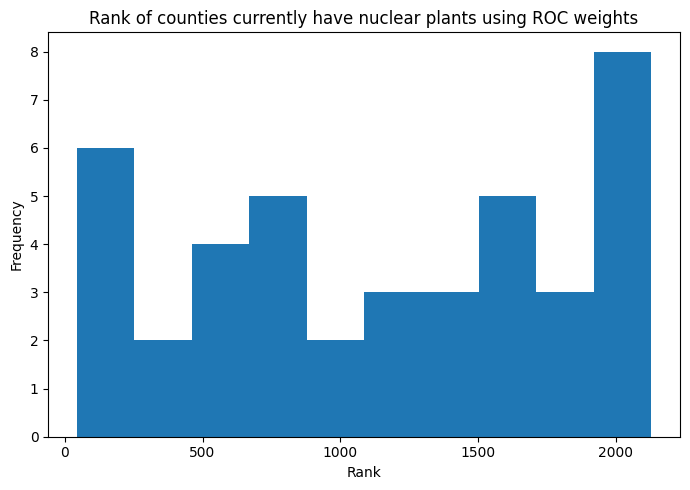

In [13]:
plt.figure(figsize = (7, 5))

plt.hist(
    x = df[df["has_plant"] == 1]["rank"]
)

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Rank of counties currently have nuclear plants using ROC weights" \
"")
plt.tight_layout()

In [14]:
# saving as csv to 'processed_data' folder
output_path = Path.cwd().parent.parent.joinpath('processed_data', 'candidates_ranked.csv')
df.to_csv(output_path, index=False)

## Findings/Takeaways

- Our expert-driven scoring framework identifies the Great Lakes region (Michigan - FIP Code 26, Wisconsin FIP Code 55) as the most suitable area for nuclear reactor siting, drivne by low seismic risk, minimal flood risks, and cooling water resources

- None of the top-ranked counties by our scoring have existing plants, and plant counties are spread across full ranking distribution (see histogram above)

- This finding indicates a criteria difference between modern and historical sites

- **Next step**: investigate this difference using **supervised ML models**; explore the feature importance among historical sties and compare against our framework to see how the siting philosophy has shifted

## Sensitivity Analysis

**Goal**: Adjust weights of the variables to see (1) changes in which variables change the suitability score the most and (2) whether the (top) recommendations stay stable.

In [15]:
features = list(criteria_ranking.keys())
base_scores = df['mcda_score'].copy()
base_top20 = set(df.nlargest(20, "mcda_score").index)

In [16]:
impacts, stability = {}, {}

for feature in features:
    row = {}
    low_score, high_score = None, None

    for delta in [-0.2, 0.2]:
        new_weights = criteria_weights.copy()
        new_weights[feature] = new_weights[feature] * (1 + delta)
        total = sum(new_weights.values())
        new_weights = {k: v/total for k, v in new_weights.items()}  
        new_scores = sum(df_scaled[f] * w for f, w in new_weights.items())
        new_top20 = set(new_scores.nlargest(20).index)
        row[f"{delta:+.0%}"] = len(new_top20 & base_top20)

        if delta < 0:
            low_score = new_scores.mean()
        else:
            high_score = new_scores.mean()

    impacts[feature] = (low_score, high_score)
    stability[feature] = row

df_stability = pd.DataFrame(stability).T
base_score = base_scores.mean()
impacts = dict(sorted(impacts.items(), key = lambda x: abs(x[1][1] - x[1][0])))

In [17]:
impacts

{'pct_protected': (np.float64(0.6120545980830171),
  np.float64(0.6125661839137031)),
 'pct_sfha': (np.float64(0.6112528169265452), np.float64(0.6132970191406327)),
 'pct_military': (np.float64(0.6112298081968882),
  np.float64(0.6133854243393349)),
 'max_voltage': (np.float64(0.614964845962675),
  np.float64(0.6097014167318552)),
 'data_centers_count': (np.float64(0.6151127064886296),
  np.float64(0.609534283381904)),
 'pga_max': (np.float64(0.6085899471453795), np.float64(0.6156655917870936)),
 'total_energy_consumption_mwh': (np.float64(0.6161348647092589),
  np.float64(0.6085354356045402)),
 'distance_to_lines_km': (np.float64(0.6080640545209256),
  np.float64(0.6164659676883645)),
 'dist_to_lakes_km': (np.float64(0.6045808595389924),
  np.float64(0.6197202142671806)),
 'total_lake_area': (np.float64(0.6206240146443368),
  np.float64(0.6042216105469423)),
 'population_density': (np.float64(0.601920894156524),
  np.float64(0.6221598109182745)),
 'avg_vol': (np.float64(0.622831444627

In [18]:
stability

{'pga_max': {'-20%': 20, '+20%': 19},
 'pct_sfha': {'-20%': 19, '+20%': 18},
 'population_density': {'-20%': 20, '+20%': 20},
 'dist_to_lakes_km': {'-20%': 19, '+20%': 20},
 'avg_vol': {'-20%': 19, '+20%': 19},
 'total_lake_area': {'-20%': 18, '+20%': 20},
 'distance_to_lines_km': {'-20%': 20, '+20%': 20},
 'max_voltage': {'-20%': 20, '+20%': 18},
 'total_energy_consumption_mwh': {'-20%': 20, '+20%': 20},
 'data_centers_count': {'-20%': 20, '+20%': 20},
 'pct_military': {'-20%': 20, '+20%': 20},
 'pct_protected': {'-20%': 19, '+20%': 20}}

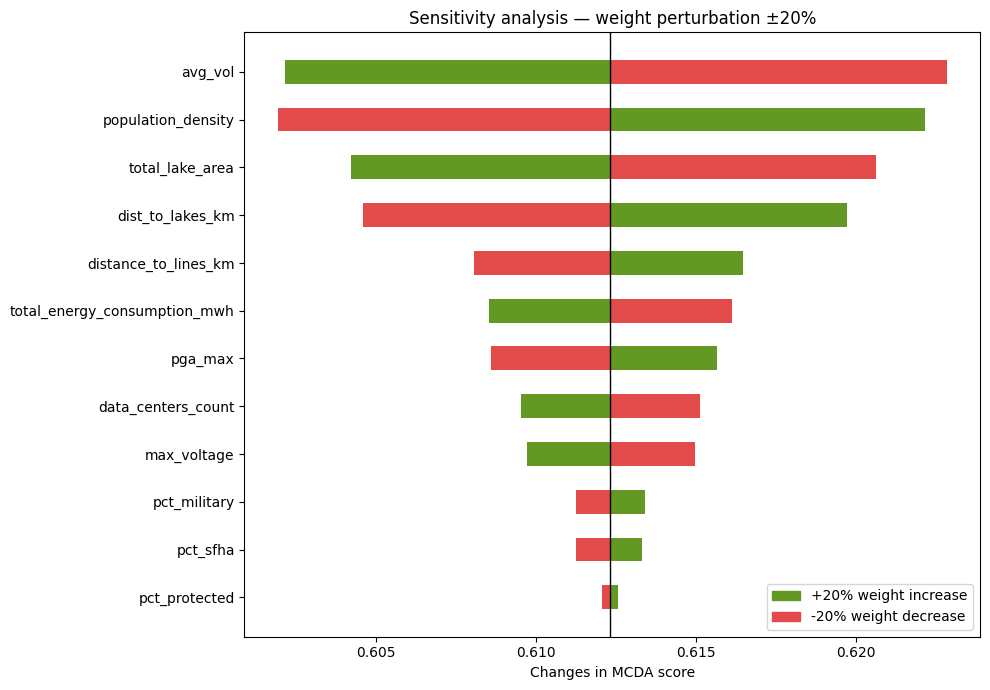

In [20]:
# changes in weights of what factors are the score most sensitive to

fig, ax = plt.subplots(figsize = (10, 7))

for index, (feature, (low, high)) in enumerate(impacts.items()):
    ax.barh(index, high - base_score, left = base_score, color = "#639922", height = 0.5)
    ax.barh(index, low - base_score, left = base_score, color = "#E24B4A", height = 0.5)

green_patch = mpatches.Patch(color = "#639922", label = "+20% weight increase")
red_patch = mpatches.Patch(color = "#E24B4A", label = "-20% weight decrease")

ax.set_xlabel("Changes in MCDA score")
ax.set_yticks(range(len(impacts)))
ax.set_yticklabels(list(impacts.keys()))
ax.set_title("Sensitivity analysis — weight perturbation ±20%")
ax.axvline(base_score, color = "black", linewidth = 1)

ax.legend(handles=[green_patch, red_patch], loc="lower right")
plt.tight_layout()
plt.savefig("../../results/sensitivity_weights_score.png", bbox_inches = "tight")

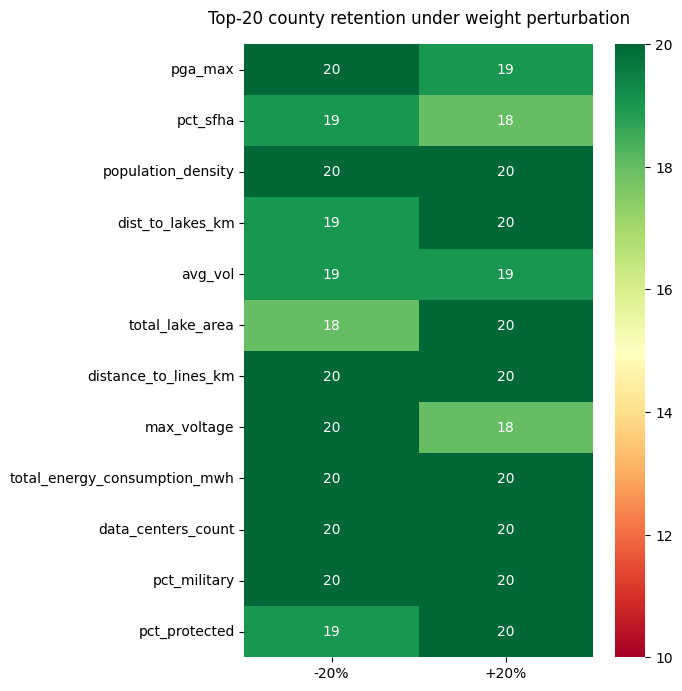

In [22]:
# heatmap of how many counties in the top 20 are retained under weight changes

plt.figure(figsize = (7, 7))

sns.heatmap(
    data = df_stability, 
    annot = True,
    fmt = "d",
    cmap = "RdYlGn",
    vmin = 10,
    vmax = 20
)

plt.title("Top-20 county retention under weight perturbation", y = 1.02)
plt.tight_layout()
plt.savefig("../../results/top_20_by_weights_changes.png", bbox_inches = "tight")

In [23]:
iterations = 1000
retention_counts = []

for i in range(iterations):
    change = np.random.uniform(0.8, 1.2, len(features))
    new_weights_all = {f: criteria_weights[f] * n for f, n in zip(features, change)}
    total_all = sum(new_weights_all.values())
    new_weights_all = {k: w/total_all for k, w in new_weights_all.items()}
    new_scores_all = sum(df_scaled[f] * w for f, w in new_weights_all.items())
    new_top20_all = set(new_scores_all.nlargest(20).index)
    retention_counts.append(len(new_top20_all & base_top20))

print(f"Mean retention: {np.mean(retention_counts):.1f}/20")
print(f"Min retention: {np.min(retention_counts)}/20")
print(f"Max retention: {np.max(retention_counts)}/20")

Mean retention: 18.7/20
Min retention: 16/20
Max retention: 20/20


In [24]:
import numpy as np

mean = np.mean(retention_counts)
std = np.std(retention_counts)
n = len(retention_counts)

# 95% CI using normal approximation (large n)
ci_low = mean - 1.96 * std / np.sqrt(n)
ci_high = mean + 1.96 * std / np.sqrt(n)

print(f"Mean retention: {mean:.2f}/20")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Std: {std:.2f}")

Mean retention: 18.71/20
95% CI: [18.66, 18.76]
Std: 0.79


In [25]:
arr = np.array(retention_counts)
sampling_mean = []

for _ in range(5000):
    sample = np.random.choice(arr, size = len(arr), replace = True)
    sampling_mean.append(np.mean(sample))

ci_95 = np.percentile(sampling_mean, [2.5, 97.5])
print(f"95% CI of average county retention in top 20: {ci_95}")

95% CI of average county retention in top 20: [18.665 18.762]


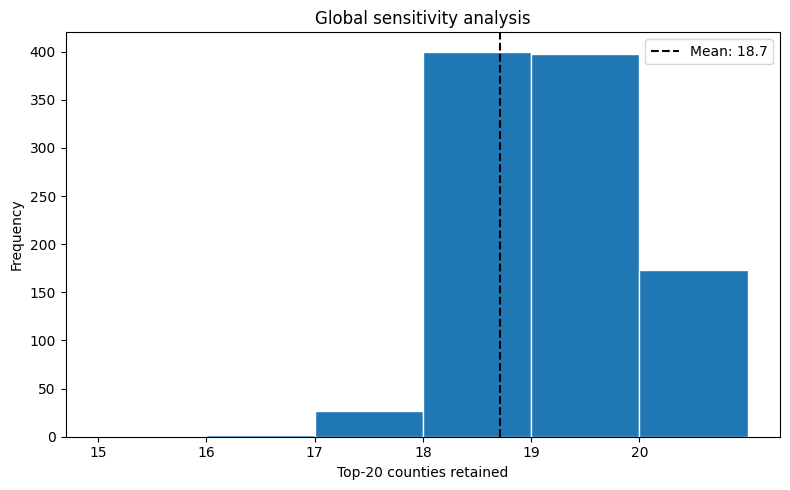

In [26]:
plt.figure(figsize = (8, 5))
plt.hist(
    retention_counts, 
    bins = range(15, 22), 
    edgecolor="white"
)
plt.axvline(
    np.mean(retention_counts), 
    color = "black", 
    linestyle = "--", 
    label = f"Mean: {np.mean(retention_counts):.1f}"
)
plt.xlabel("Top-20 counties retained")
plt.ylabel("Frequency")
plt.title("Global sensitivity analysis")
plt.xticks(range(15, 21))
plt.legend()
plt.tight_layout()
plt.show()

## Findings/Takeaways

- The most important factors in our scoring framework are `pga_max`, `pcf_sfha`, `population_density` (highest weights)

- For the first sensitivity analysis where only one variable was changed at a time, our scores are most sensitive to change in `avg_vol`, `population_density`, `total_lake_area`. Some low-weighted factors might have high impact on the final scores, while other high-weighted like `pga_max` might have lower impact. Note that this reflects score sensitivity, not variable importance (which is defined separately by our weights)

- Although the sensitivity ranking doesn't reflect our importance ranking, changing one weight by 20% doesn't make our recommendations less stable as shown by the heatmap. If we change the weight of one variable, nearly all counties in the top 20 remain the same, which suggests that our scoring framework is robust to a certain degree

- To further validate our framework, we did sensitivity analysis globally where we slightly change the weights of all variables at a time over 1000 simulations. On average, the mean county retention is the top 20 was **18.8 counties** (min = 17, max = 20), with a **95% CI of [18.744 18.847]**. This is **93.53%**, which confirms that our recommendations are robust and stable even if the weights might be imperfect.